# Energy usage analysis 

In [1]:
%matplotlib inline
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

from pandas import DataFrame

from easyvvuq.analysis.sc_analysis import SCAnalysisResults

from typing import cast

from src import machines
from src import programs
from src import energyuq
from src.util import plot

/home/mmachado/HPC/uq_sbac/.venv/lib/python3.14/site-packages/chaospy/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Restore data from most recent run 

In [2]:
campaign_name = "energy"
campaign, analysis = energyuq.load(programs.FFT, machines.Glados, campaign_name)

sampler = energyuq.get_sampler(campaign)
qoi_cols = analysis.qoi_cols
qoi = "energy_uj"
results = cast(SCAnalysisResults, campaign.get_last_analysis()) # better linting
df = campaign.get_collation_result()


/home/mmachado/HPC/uq_sbac/.venv/lib/python3.14/site-packages/cerberus/validator.py:618: UserWarning: These types are defined both with a method and in the'types_mapping' property of this validator: {'integer'}
  warn(


## Plots

1. Which points were chosen and ran

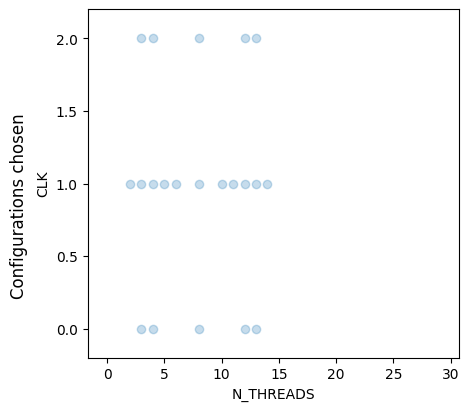

In [3]:
plot.plot_grid_2D(analysis, sampler)

2. Which configurations consumed less energy in total

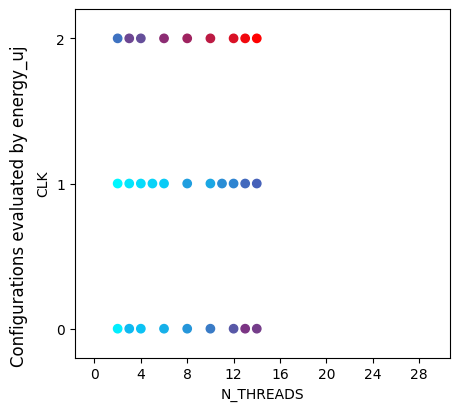

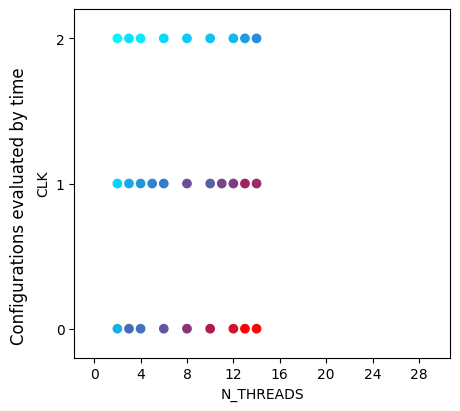

In [4]:
plot.plot_grid_2D_best(df, qoi, (qoi, 0))
plot.plot_grid_2D_best(df, "time", ("time", 0))

3. What is the difference between the best and worst configurations?

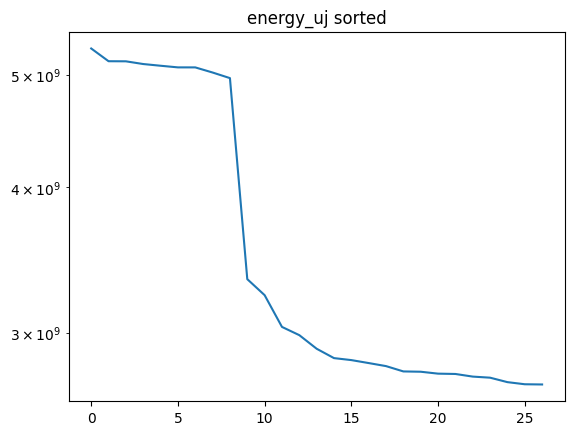

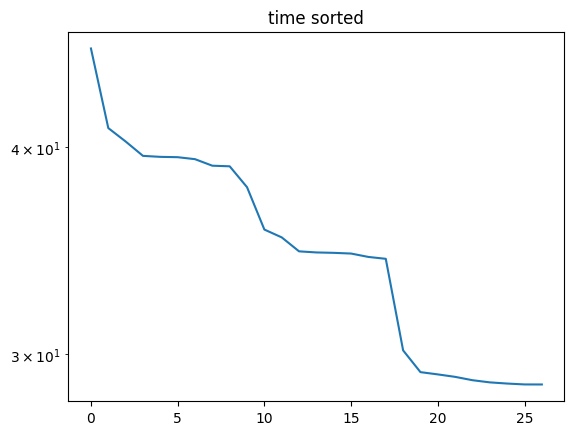

In [ ]:
plot.plot_sorted(df, qoi)
plot.plot_sorted(df, "time")

4. View of the resulting energy usage against each parameter

ValueError: Grouper for 'N_THREADS' not 1-dimensional

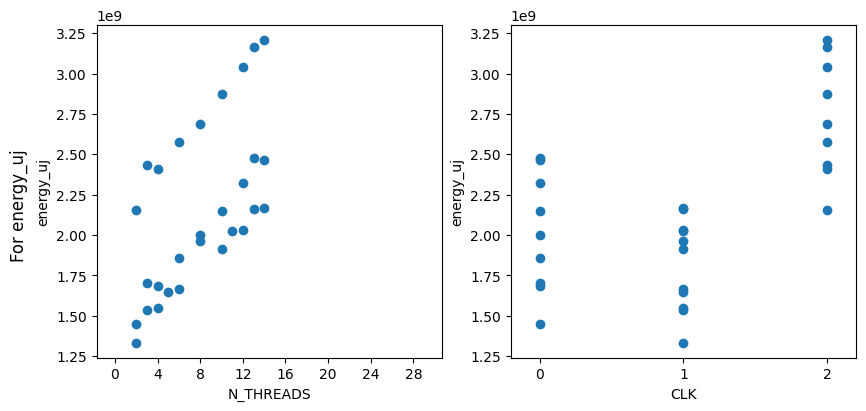

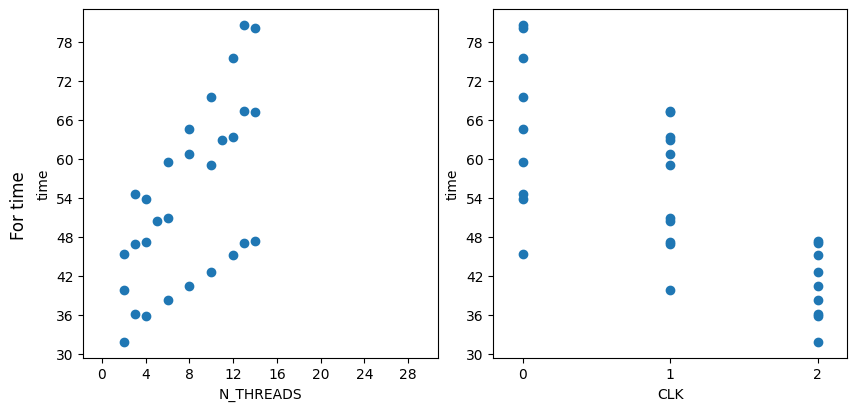

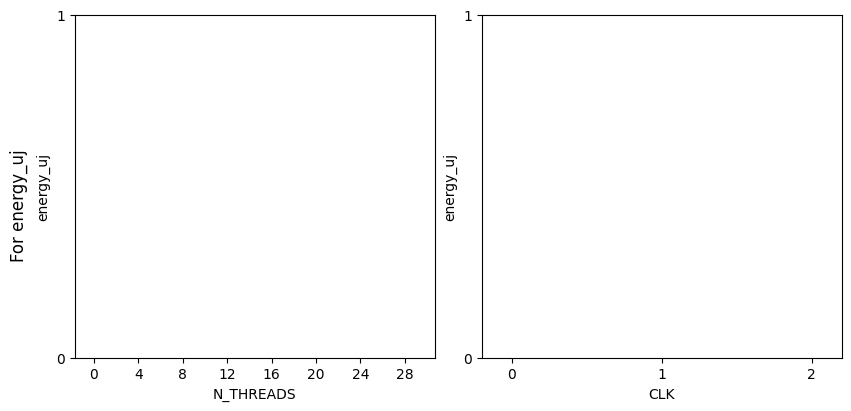

In [5]:
plot.plot_2D_single_dimension(df, qoi)
plot.plot_2D_single_dimension(df, "time")
plot.plot_boxplot(df, qoi)
plot.plot_boxplot(df, "time")

5. First order sobol indices and decomposition treemap

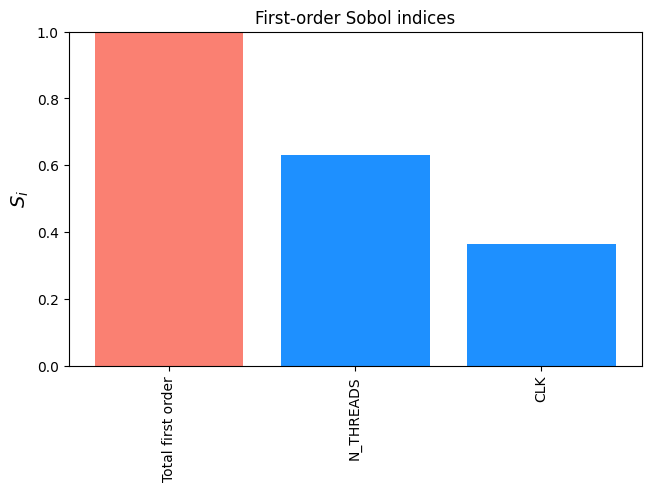

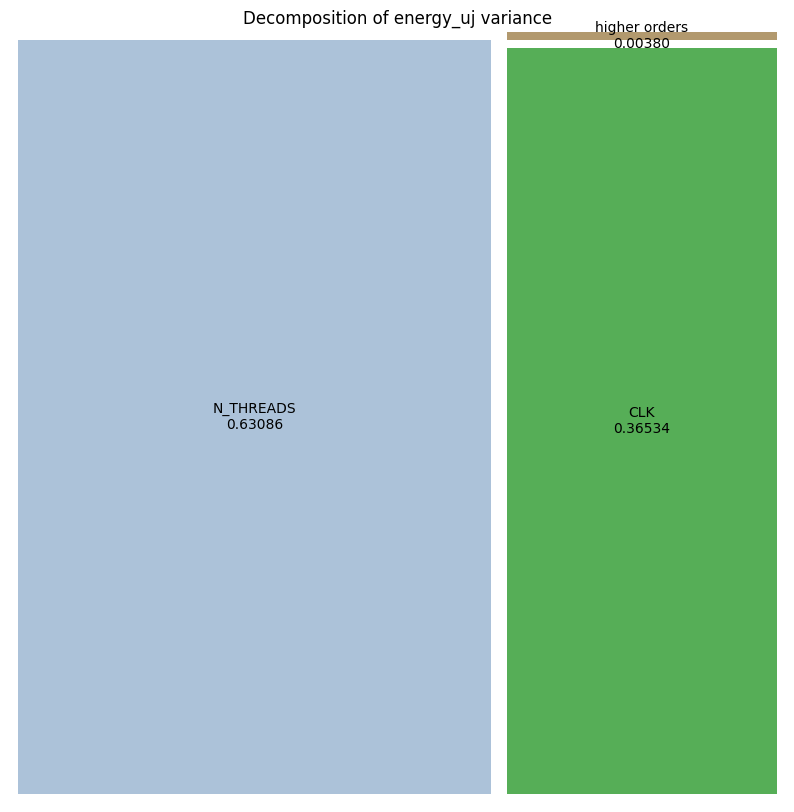

In [6]:
for qoi in qoi_cols:
    plot.plot_sobols1(results, qoi)
    results.plot_sobols_treemap(qoi, figsize=(10, 10))
    plt.axis('off')

6. Adaptation table, histogram and errors

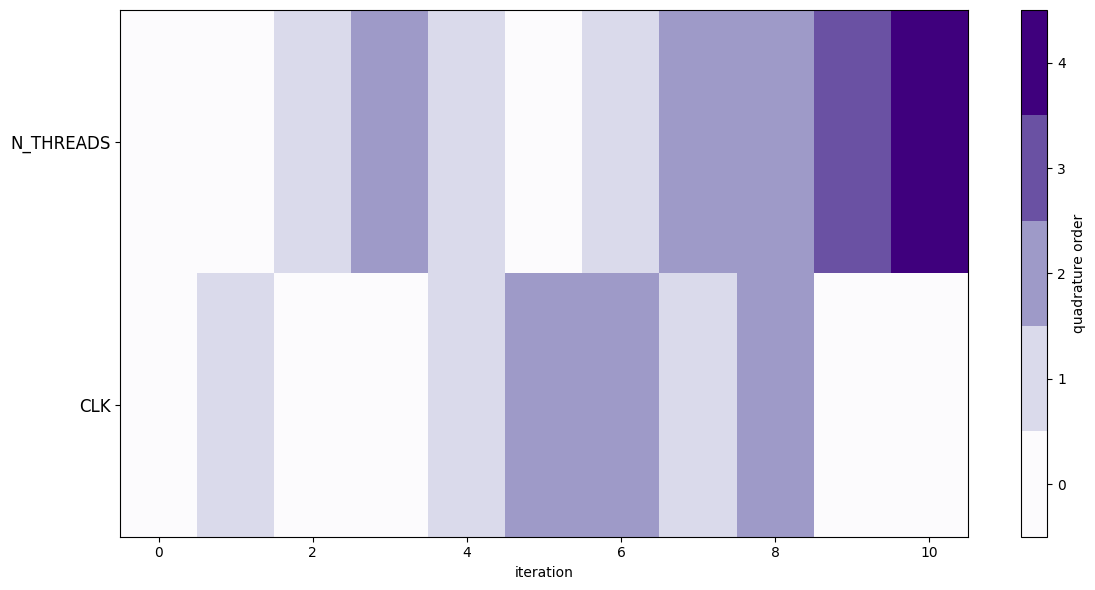

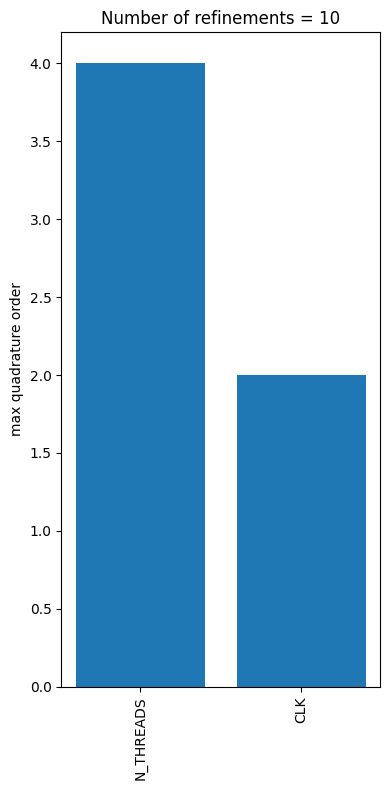

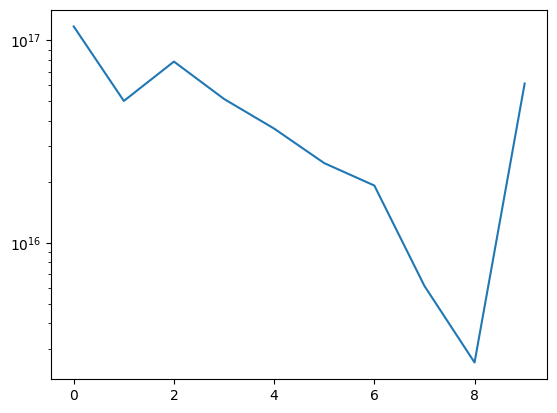

In [7]:
analysis.adaptation_table()
analysis.adaptation_histogram()
plt.semilogy(analysis.get_adaptation_errors())

7. Uncertainty amplification and stat convergence

-----------------
Mean CV input = 67.8279 %
Mean CV output = 24.8147 %
Uncertainty amplification factor = 0.2481/0.6783 = 0.3658
-----------------


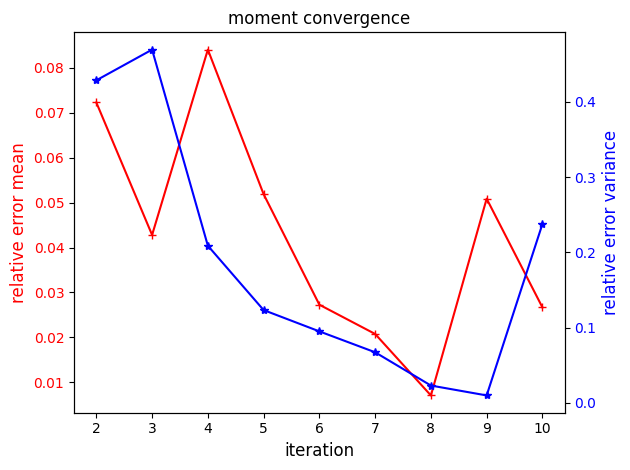

In [8]:
analysis.get_uncertainty_amplification(qoi)
analysis.plot_stat_convergence()